In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

%precision 3
%matplotlib inline

In [8]:
# 그래프 선의 종류
linestyles = ['-', '--', ':']

def E(X, g=lambda x: x) :
    x_set, f = X
    return np.sum([g(x_k) * f(x_k) for x_k in x_set])

def V(X, g=lambda x: x) :
    x_set, f = X
    mean = E(X, g)
    return np.sum([(g(x_k) - mean)**2 * f(x_k) for x_k in x_set])

def check_prob(X) :
    x_set, f = X
    prob = np.array([f(x_k) for x_k in x_set])
    assert np.all(prob >= 0), 'minus probability'
    prob_sum = np.round(np.sum(prob), 6)
    assert prob_sum == 1, f'sum of probability is {prob_sum}'
    print(f'expected value (E(X)): {E(X):.4}')
    print(f'variance (V(X)): {V(X):.4}')

def plot_prob(X) :
    x_set, f = X
    prob = np.array([f(x_k) for x_k in x_set])

    
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111)
    ax.bar(x_set, prob, label='prob')
    ax.vlines(E(X), 0, 1, label='mean')
    ax.set_xticks(np.append(x_set, E(X)))
    ax.set_ylim(0, prob.max() * 1.2)
    ax.legend()
    
    plt.show()

In [9]:
def Bern(p) :
    x_set = np.array([0, 1])
    def f(x) :
        if x in x_set :
            return p**x * (1-p)**(1-x)
        else :
            return 0
    return x_set, f

In [10]:
p = 0.3
X = Bern(p)

In [12]:
check_prob(X)

expected value (E(X)): 0.3
variance (V(X)): 0.21


In [13]:
rv = stats.bernoulli(p)

In [14]:
rv.pmf(0), rv.pmf(1)

(0.700, 0.300)

In [15]:
rv.pmf([0,1])

array([0.7, 0.3])

In [16]:
rv.cdf([0,1])

array([0.7, 1. ])

In [17]:
rv.mean(), rv.var()

(0.300, 0.210)

In [19]:
from scipy.special import comb

def Bin(n, p) :
    x_set = np.arange(n + 1)
    def f(x) :
        if x in x_set :
            return comb(n, x) * p**x * (1 - p)**(n - x)
        else :
            return 0
    return x_set, f

In [21]:
n = 10
p = 0.3
X = Bin(n,p)

In [22]:
check_prob(X)

expected value (E(X)): 3.0
variance (V(X)): 2.1


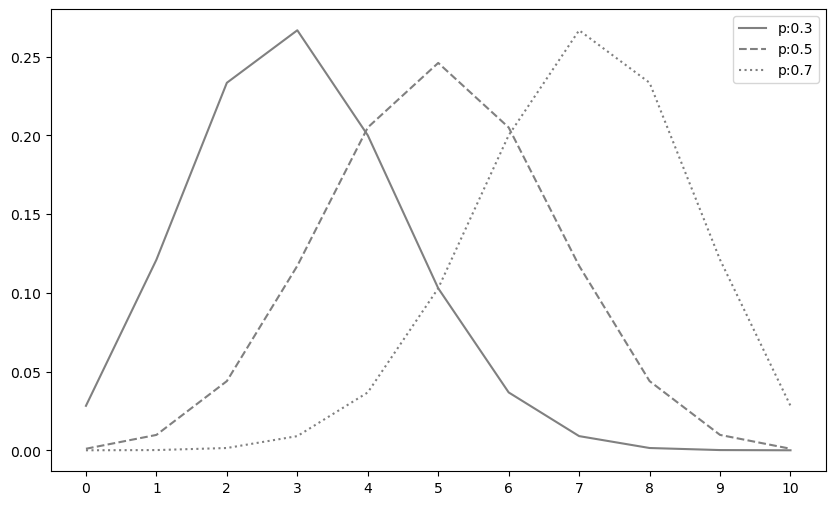

In [23]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

x_set = np.arange(n + 1)
for p, ls in zip([0.3, 0.5, 0.7], linestyles) :
    rv = stats.binom(n, p)
    ax.plot(x_set, rv.pmf(x_set),
            label=f'p:{p}', ls=ls, color='gray')
ax.set_xticks(x_set)
ax.legend()

plt.show()

In [24]:
def Ge(p) :
    x_set = np.arange(1, 30)
    def f(x) :
        if x in x_set :
            return p * (1 - p)**(x - 1)
        else :
            return 0
    return x_set, f

In [25]:
p = 0.5
X = Ge(p)

In [26]:
check_prob(X)

expected value (E(X)): 2.0
variance (V(X)): 2.0


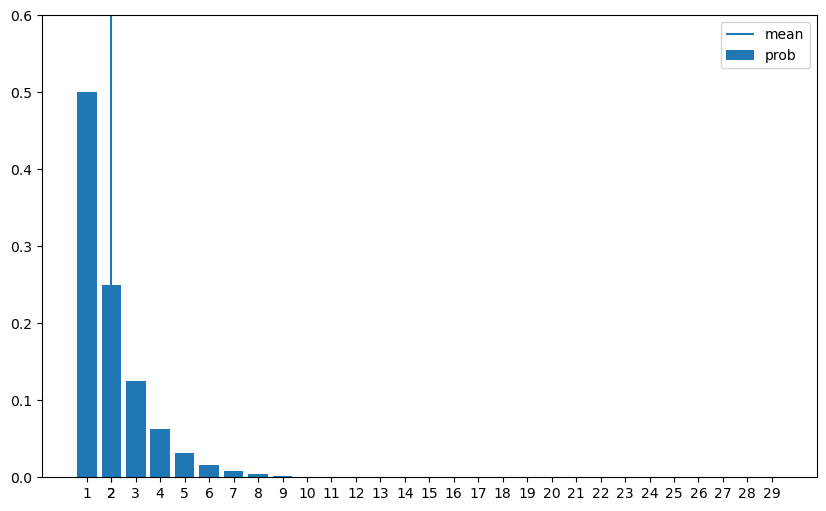

In [27]:
plot_prob(X)

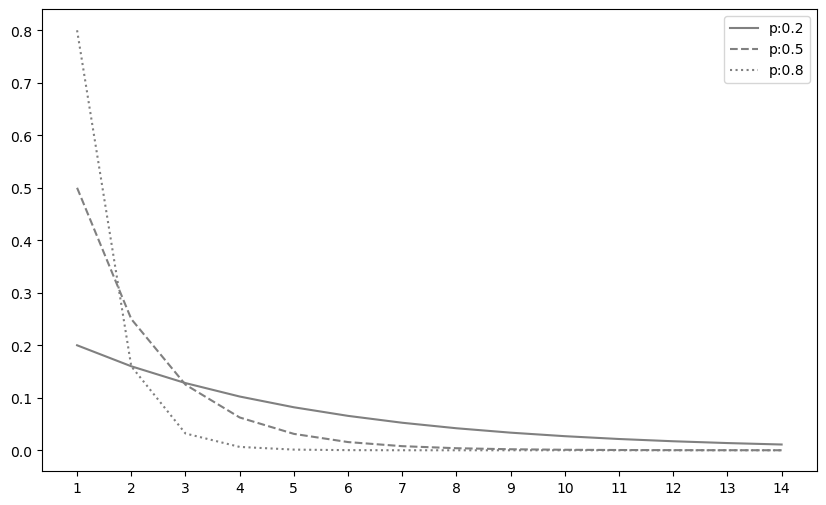

In [30]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

x_set = np.arange(1, 15)
for p, ls in zip([0.2, 0.5, 0.8], linestyles) :
    rv = stats.geom(p)
    ax.plot(x_set, rv.pmf(x_set),
            label=f'p:{p}', ls=ls, color='gray')
ax.set_xticks(x_set)
ax.legend()

plt.show()

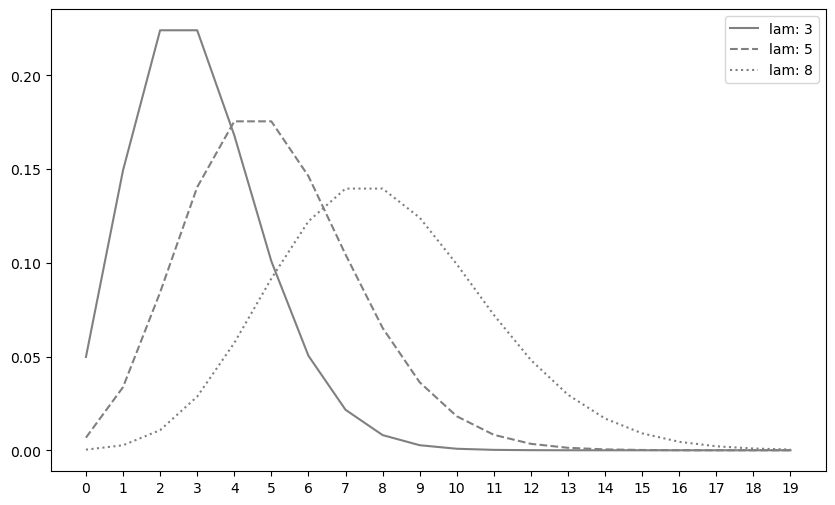

In [31]:
from scipy.special import factorial

def Poi(lam) :
    x_set = np.arange(20)
    def f(x) :
        if x in x_set :
            return np.power(lam, x) / factorial(x) * np.exp(-lam)
        else :
            return 0
    return x_set, f



In [33]:
lam = 3
X = Poi(lam)

In [34]:
check_prob(X)

expected value (E(X)): 3.0
variance (V(X)): 3.0


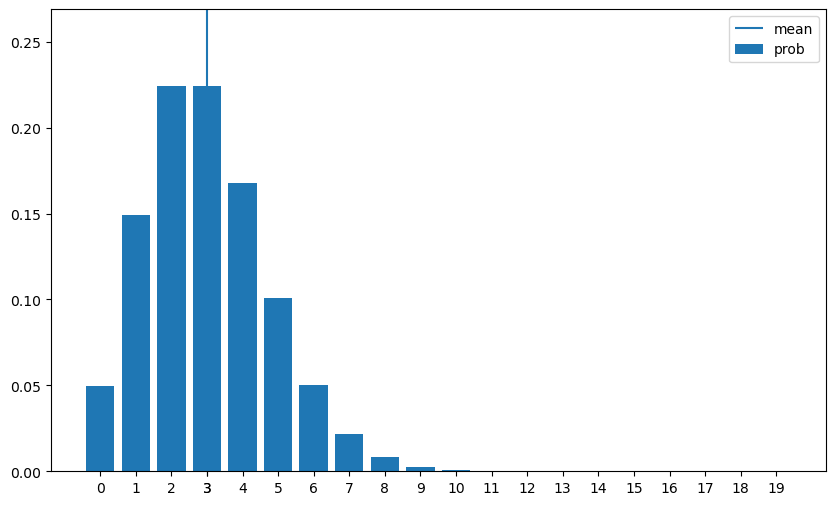

In [35]:
plot_prob(X)

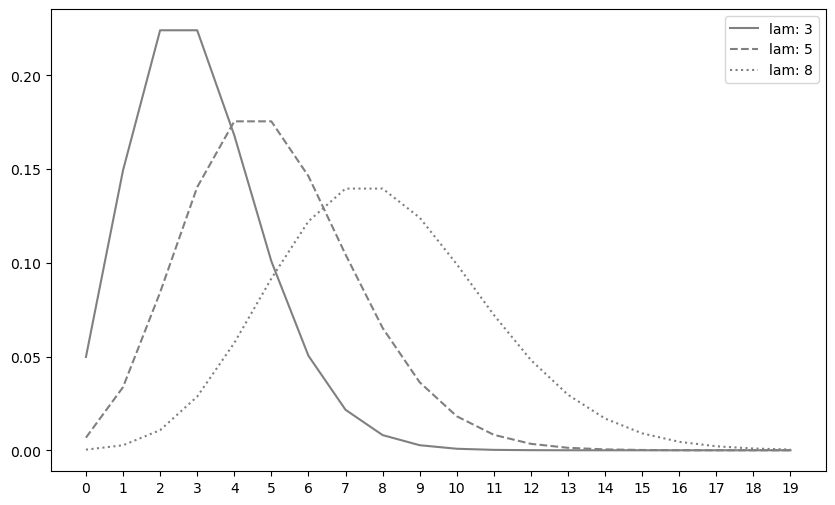

In [36]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

x_set = np.arange(20)
for lam, ls in zip([3, 5, 8], linestyles) :
    rv = stats.poisson(lam)
    ax.plot(x_set, rv.pmf(x_set),
            label=f'lam: {lam}', ls=ls, color='gray')
ax.set_xticks(x_set)
ax.legend()

plt.show()